Train & Visualize Decision Tree

     age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0   52.0  1.0  0.0     125.0  212.0  0.0      1.0    168.0      0      1.0   
1   53.0  1.0  0.0     140.0  203.0  1.0      0.0    155.0      1      3.1   
2   70.0  1.0  0.0     145.0  174.0  0.0      1.0    125.0      1      2.6   
4   62.0  0.0  0.0     138.0  294.0  1.0      1.0    106.0      0      1.9   
7   55.0  1.0  0.0     160.0  289.0  0.0      0.0    145.0      1      0.8   
11  43.0  0.0  0.0     132.0  341.0  1.0      0.0    136.0      1      3.0   
12  34.0  0.0  1.0     118.0  210.0  0.0      1.0    192.0      0      0.7   
16  51.0  0.0  2.0     140.0  308.0  0.0      0.0    142.0      0      1.5   
17  54.0  1.0  0.0     124.0  266.0  0.0      0.0    109.0      1      2.2   
19  58.0  1.0  2.0     140.0  211.0  1.0      0.0    165.0      0      0.0   
23  63.0  0.0  2.0     135.0  252.0  0.0      0.0    172.0      0      0.0   
24  42.0  0.0  2.0     120.0  209.0  0.0      1.0    173.0      

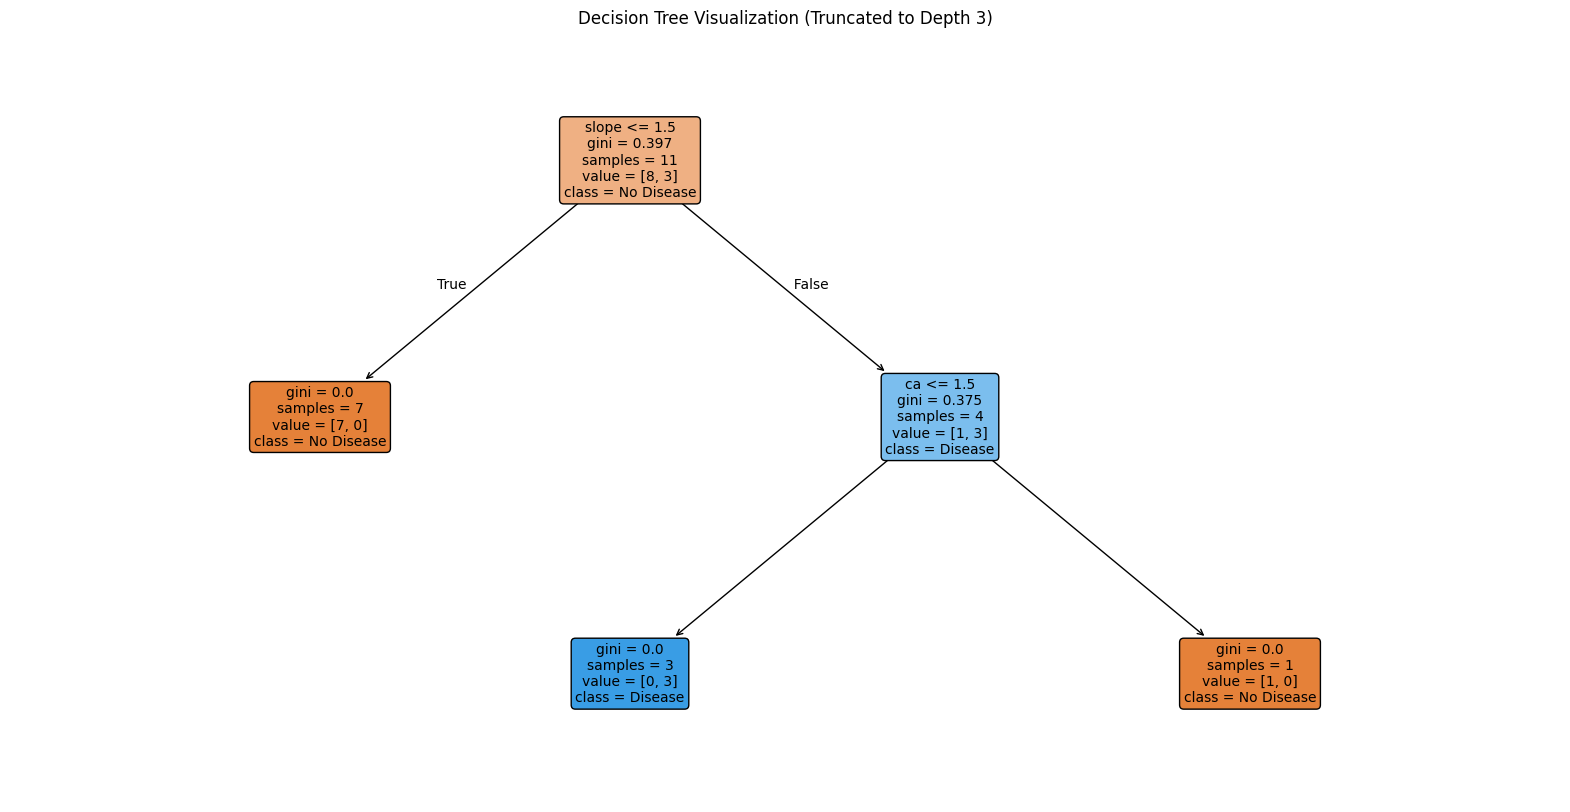

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv('C:/Users/Administrator/Documents/Dhruvil/Projects/Data Science/Data Science xl files/heart.csv')
df = df.dropna()
print(df)
X = df.drop('target', axis=1)
y = df['target']

# Split the dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
# Limiting depth to 3 just for a readable visualization
plot_tree(dt, feature_names=X.columns, class_names=['No Disease', 'Disease'], 
          filled=True, rounded=True, max_depth=3, fontsize=10)
plt.title("Decision Tree Visualization (Truncated to Depth 3)")
plt.show()

Analyze Overfitting & Control Depth

In [4]:
train_acc_unpruned = accuracy_score(y_train, dt.predict(X_train))
test_acc_unpruned = accuracy_score(y_test, dt.predict(X_test))

# Train a constrained (pruned) tree
dt_pruned = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_pruned.fit(X_train, y_train)
train_acc_pruned = accuracy_score(y_train, dt_pruned.predict(X_train))
test_acc_pruned = accuracy_score(y_test, dt_pruned.predict(X_test))

print("--- Overfitting Analysis ---")
print(f"Unpruned Tree -> Train Acc: {train_acc_unpruned:.3f} | Test Acc: {test_acc_unpruned:.3f}")
print(f"Pruned Tree   -> Train Acc: {train_acc_pruned:.3f} | Test Acc: {test_acc_pruned:.3f}\n")


--- Overfitting Analysis ---
Unpruned Tree -> Train Acc: 1.000 | Test Acc: 0.667
Pruned Tree   -> Train Acc: 1.000 | Test Acc: 0.667



Train Random Forest & Compare

In [5]:
rf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
rf.fit(X_train, y_train)
rf_test_acc = accuracy_score(y_test, rf.predict(X_test))

print("--- Random Forest Comparison ---")
print(f"Random Forest Test Acc: {rf_test_acc:.3f}\n")

--- Random Forest Comparison ---
Random Forest Test Acc: 0.667



Interpret Feature Importances

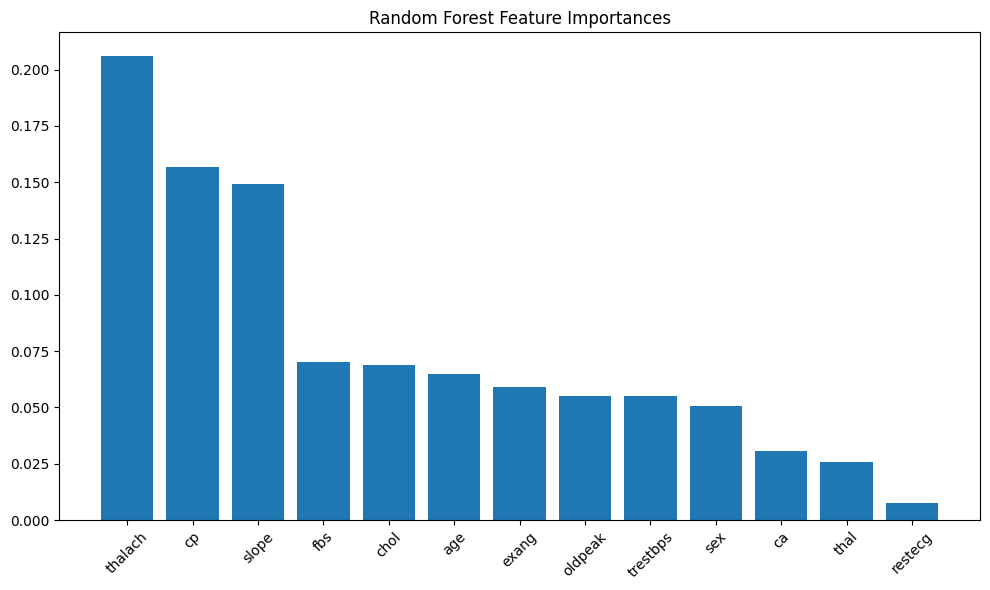

In [6]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Random Forest Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

Evaluate using Cross-Validation

In [7]:
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
print("--- Cross-Validation ---")
print(f"5-Fold CV Scores: {np.round(cv_scores, 3)}")
print(f"Mean CV Accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

--- Cross-Validation ---
5-Fold CV Scores: [0.667 0.667 0.667 0.667 1.   ]
Mean CV Accuracy: 0.733 (+/- 0.267)
